# Book - Modern Time Series Forecasting with Python

## Chapter 15 - Time Series Forecasting in Practice: Case Studies


### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.23.5
* sklearn: 1.3.2
* seaborn: 0.13.2
* statsmodels: 0.14.1
* tensorflow: 2.12.0
* keras: 2.12.0
* yfinance: 0.2.65

In [1]:
import warnings
warnings.filterwarnings('ignore') 

## <span style="color:blue"> Case Study 1: Demand Forecasting with SARIMA

#### Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error
# Use pandas_datareader to fetch data from FRED
import pandas_datareader.data as web

#### Exploratory Data Analysis (EDA)

--- Exploratory Data Analysis ---


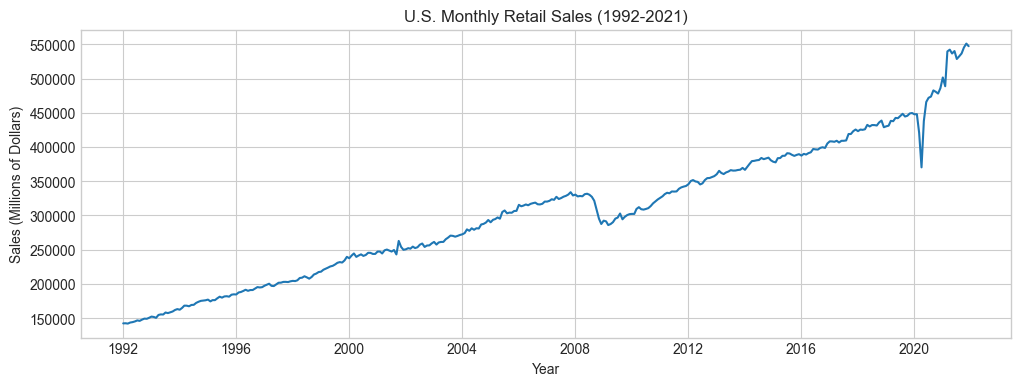


--- Time Series Decomposition ---


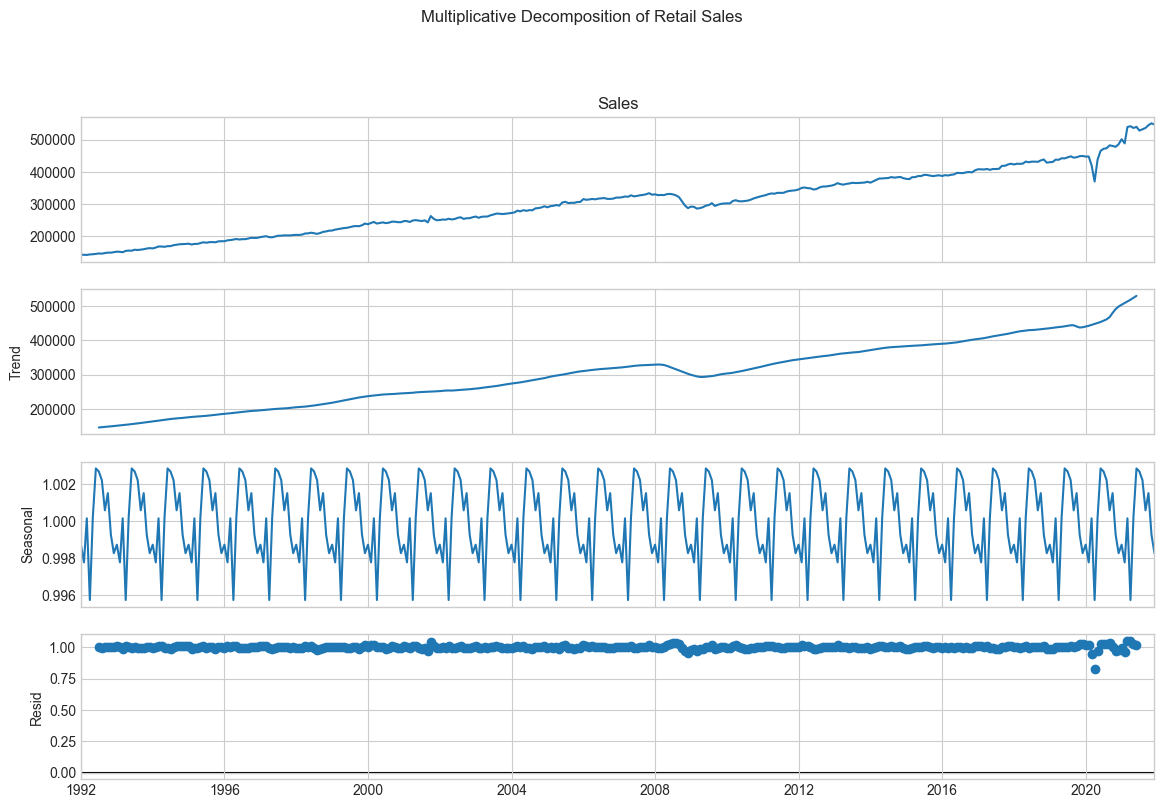

In [2]:
# Fetch the data from FRED (Advance Retail Sales: Retail Trade and Food Services)
# Series ID for unadjusted data is RSXFS
start_date = '1992-01-01'
end_date = '2021-12-31'
retail_sales = web.DataReader('RSXFS', 'fred', start_date, end_date)
retail_sales.columns = ['Sales']

# 1. Time Plot of the original series
print("--- Exploratory Data Analysis ---")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(retail_sales.index, retail_sales['Sales'])
ax.set_title('U.S. Monthly Retail Sales (1992-2021)')
ax.set_xlabel('Year')
ax.set_ylabel('Sales (Millions of Dollars)')
ax.grid(True)
plt.show()

# 2. Time Series Decomposition
# The visual inspection suggests multiplicative seasonality
print("\n--- Time Series Decomposition ---")
decomposition = sm.tsa.seasonal_decompose(retail_sales['Sales'], model='multiplicative')

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Multiplicative Decomposition of Retail Sales', y=1.02)
plt.tight_layout(pad=2.0)
plt.show()

#### Data Preprocessing and Stationarity


--- Visualizing the Stationarity Transformation Process ---


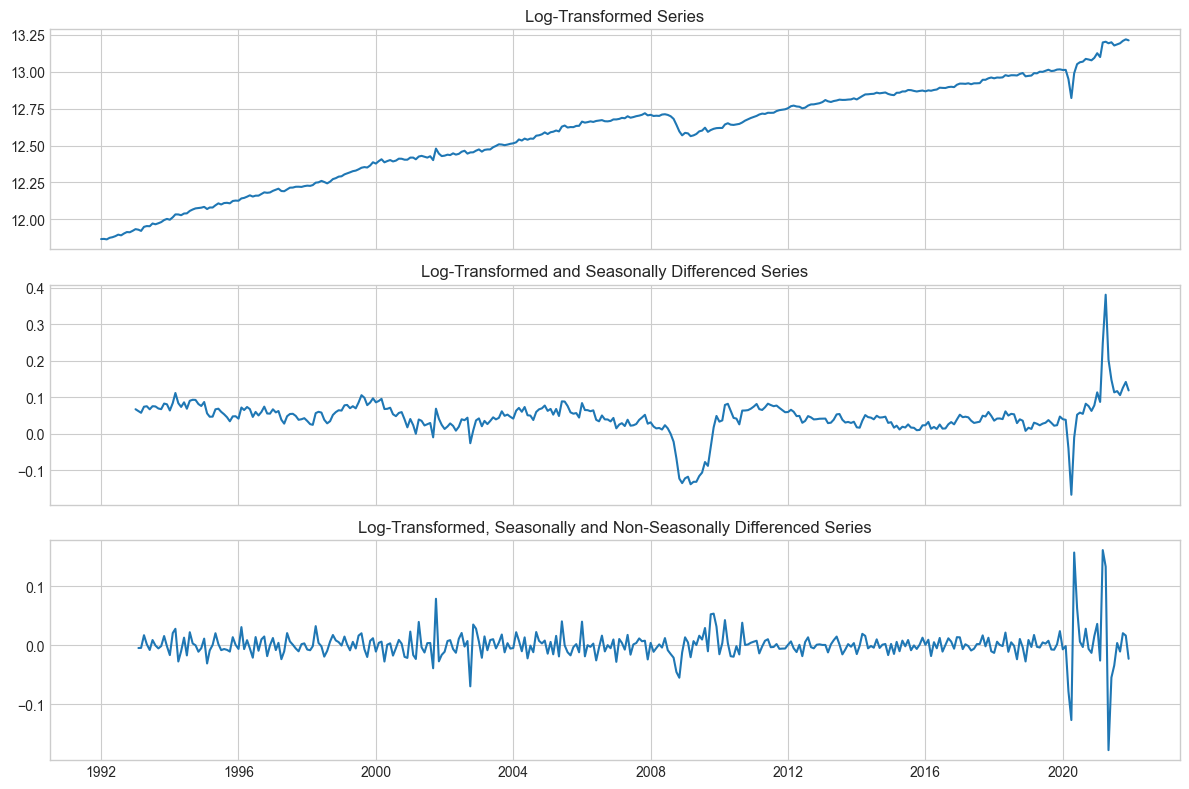


--- Augmented Dickey-Fuller Test on Final Series ---
ADF Statistic: -7.8379
p-value: 0.0000
Critical Values:
	1%: -3.450
	5%: -2.870
	10%: -2.571

Conclusion: The series is stationary (reject H0). We can proceed with p,q,P,Q identification.


In [3]:
# --- Data Preprocessing and Stationarity ---

# Log transformation to stabilize variance
retail_sales['log_sales'] = np.log(retail_sales['Sales'])

# Seasonal differencing (lag=12 for annual seasonality)
retail_sales['log_seasonal_diff'] = retail_sales['log_sales'].diff(12)

# Non-seasonal differencing
retail_sales['log_seasonal_nons_diff'] = retail_sales['log_seasonal_diff'].diff(1)

# Drop NaN values created by differencing for analysis
stationary_series_retail = retail_sales['log_seasonal_nons_diff'].dropna()

# --- Visualizing the Transformation Process ---
print("\n--- Visualizing the Stationarity Transformation Process ---")
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(retail_sales['log_sales'])
axes[0].set_title('Log-Transformed Series')
axes[0].grid(True)

axes[1].plot(retail_sales['log_seasonal_diff'])
axes[1].set_title('Log-Transformed and Seasonally Differenced Series')
axes[1].grid(True)

axes[2].plot(stationary_series_retail)
axes[2].set_title('Log-Transformed, Seasonally and Non-Seasonally Differenced Series')
axes[2].grid(True)

plt.tight_layout()
plt.show()


# --- ADF Test for Stationarity on the final differenced series ---
print("\n--- Augmented Dickey-Fuller Test on Final Series ---")
adf_result_retail = adfuller(stationary_series_retail)

print(f'ADF Statistic: {adf_result_retail[0]:.4f}')
print(f'p-value: {adf_result_retail[1]:.4f}')
print('Critical Values:')
for key, value in adf_result_retail[4].items():
    print(f'\t{key}: {value:.3f}')

if adf_result_retail[1] <= 0.05:
    print("\nConclusion: The series is stationary (reject H0). We can proceed with p,q,P,Q identification.")
else:
    print("\nConclusion: The series is non-stationary (fail to reject H0). Further differencing may be needed.")


#### Model Identification, Fitting, and Diagnostics


--- Model Identification ---


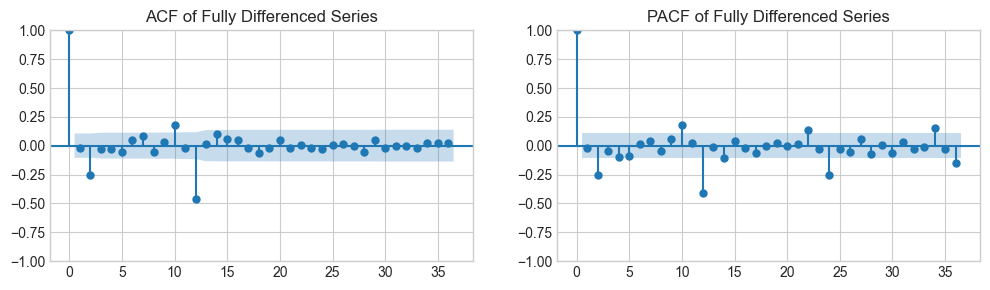


--- Fitting SARIMA(0,1,1)(0,1,1,12) Model ---


/Users/ravindra/opt/anaconda3/envs/research38/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ravindra/opt/anaconda3/envs/research38/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          log_sales   No. Observations:                  360
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 866.976
Date:                            Wed, 10 Dec 2025   AIC                          -1727.952
Time:                                    07:58:50   BIC                          -1716.528
Sample:                                01-01-1992   HQIC                         -1723.396
                                     - 12-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1405      0.012    -11.871      0.000      -0.164      -0.117
ma.S.L12      -1.0093      0.220   

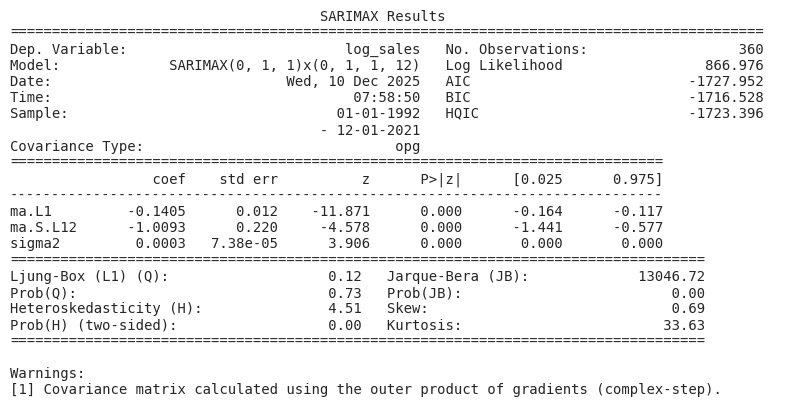


--- Model Diagnostics ---


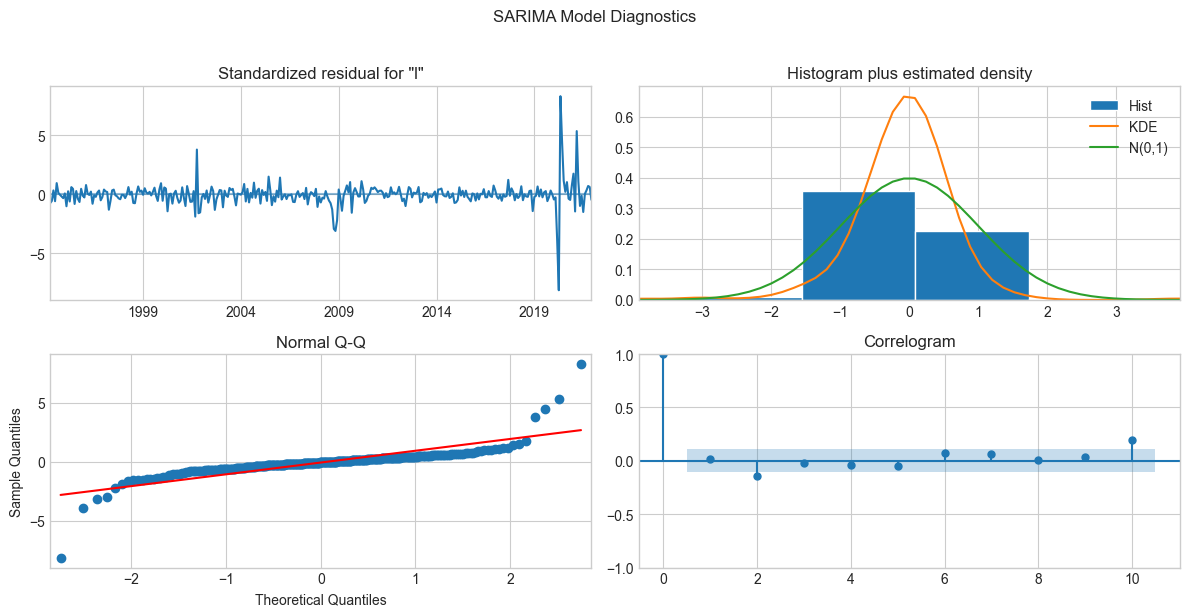

In [4]:
# --- Model Identification, Fitting, and Diagnostics ---

# 1. Model Identification using ACF and PACF plots on the stationary series
print("\n--- Model Identification ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
plot_acf(stationary_series_retail, lags=36, ax=axes[0])
axes[0].set_title('ACF of Fully Differenced Series')
plot_pacf(stationary_series_retail, lags=36, ax=axes[1])
axes[1].set_title('PACF of Fully Differenced Series')
plt.show()

# Based on the ACF/PACF, a spike at lag 1 in ACF suggests q=1.
# A spike at lag 12 in ACF suggests Q=1.
# We will start with a SARIMA(0,1,1)(0,1,1,12) model.

# 2. Model Fitting
print("\n--- Fitting SARIMA(0,1,1)(0,1,1,12) Model ---")
# We fit the model on the full log-transformed dataset for diagnostics
sarima_model_retail = sm.tsa.SARIMAX(retail_sales['log_sales'],
                                       order=(0, 1, 1),
                                       seasonal_order=(0, 1, 1, 12),
                                       enforce_stationarity=False,
                                       enforce_invertibility=False)
# Fit the model
sarima_results_retail = sarima_model_retail.fit(disp=False)

# Print model summary
print(sarima_results_retail.summary())

# Assuming var_results is already fitted
summary_text = sarima_results_retail.summary()#.as_text()

# Plot text using matplotlib
plt.figure(figsize=(10, 5))
plt.axis("off")
plt.text(0, 1, summary_text, fontsize=10, va="top", family="monospace")

plt.show()
plt.close()


# 3. Model Diagnostics
print("\n--- Model Diagnostics ---")
sarima_results_retail.plot_diagnostics(figsize=(12, 6))
plt.suptitle('SARIMA Model Diagnostics', y=1.02)
plt.tight_layout()
plt.show()


#### Forecasting and Evaluation


--- Fitting Final Model on Training Data ---


/Users/ravindra/opt/anaconda3/envs/research38/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ravindra/opt/anaconda3/envs/research38/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



--- Generating Out-of-Sample Forecasts ---
Root Mean Squared Error (RMSE) on Test Set: $43,681.21 Million

--- Plotting Forecasts vs. Actuals ---


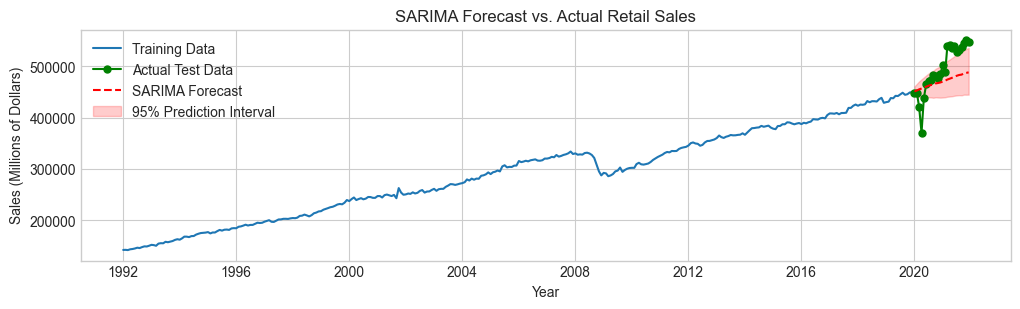

In [5]:
# --- Forecasting and Evaluation ---

# 1. Split data into training and test sets
train_end = '2019-12-31'
test_start = '2020-01-01'
train_data_retail = retail_sales.loc[:train_end, 'log_sales']
test_data_log_retail = retail_sales.loc[test_start:, 'log_sales']
actual_original_retail = retail_sales.loc[test_start:, 'Sales']


# 2. Fit the final SARIMA model on the training data
print("\n--- Fitting Final Model on Training Data ---")
sarima_model_final_retail = sm.tsa.SARIMAX(train_data_retail,
                                             order=(0, 1, 1),
                                             seasonal_order=(0, 1, 1, 12))
sarima_results_final_retail = sarima_model_final_retail.fit(disp=False)


# 3. Generate forecasts for the test period
print("\n--- Generating Out-of-Sample Forecasts ---")
forecast_steps_retail = len(test_data_log_retail)
forecast_obj_retail = sarima_results_final_retail.get_forecast(steps=forecast_steps_retail)
forecast_log_retail = forecast_obj_retail.predicted_mean
conf_int_log_retail = forecast_obj_retail.conf_int()

# 4. Back-transform forecasts and confidence intervals to the original scale
forecast_original_retail = np.exp(forecast_log_retail)
conf_int_original_retail = np.exp(conf_int_log_retail)


# 5. Evaluate the forecast using RMSE
rmse_retail = np.sqrt(mean_squared_error(actual_original_retail, forecast_original_retail))
print(f'Root Mean Squared Error (RMSE) on Test Set: ${rmse_retail:,.2f} Million')


# 6. Plot the forecasts against actual values
print("\n--- Plotting Forecasts vs. Actuals ---")
plt.figure(figsize=(12, 3))
plt.plot(retail_sales.loc[:train_end, 'Sales'], label='Training Data')
plt.plot(actual_original_retail, label='Actual Test Data', color='green', marker='o', markersize=5)
plt.plot(forecast_original_retail, label='SARIMA Forecast', color='red', linestyle='--')
plt.fill_between(conf_int_original_retail.index,
                 conf_int_original_retail.iloc[:, 0],
                 conf_int_original_retail.iloc[:, 1], color='red', alpha=0.2, label='95% Prediction Interval')
plt.title('SARIMA Forecast vs. Actual Retail Sales')
plt.xlabel('Year')
plt.ylabel('Sales (Millions of Dollars)')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


## <span style="color:blue"> Case Study 2: Energy Consumption Forecasting with XGBoost

#### Load Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error
#from xgboost.callback import EarlyStopping


# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')


#### Load the dataset

In [7]:
# Load the dataset
# Source: Kaggle - https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption
# For reproducibility, using a direct link to the data
dataset_link = './PJME_hourly.csv'
df = pd.read_csv(dataset_link)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df =df.sort_values(by='Datetime')
df = df.set_index('Datetime')

df = df.rename(columns={'PJME_MW':'energy_mw'})

#### Exploratory Data Analysis (EDA

--- Exploratory Data Analysis ---


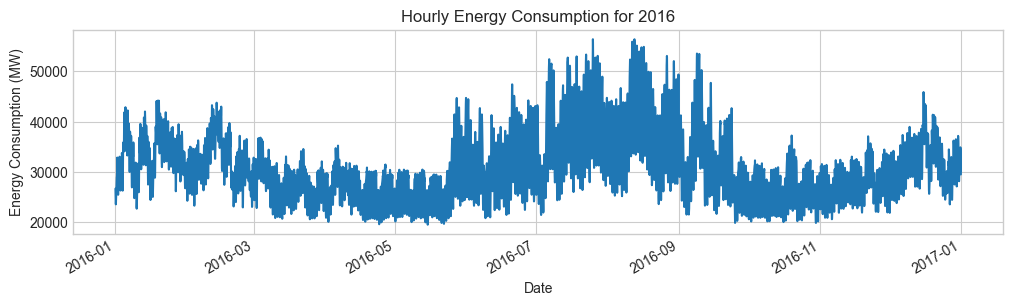


--- Visualizing Daily Seasonality ---


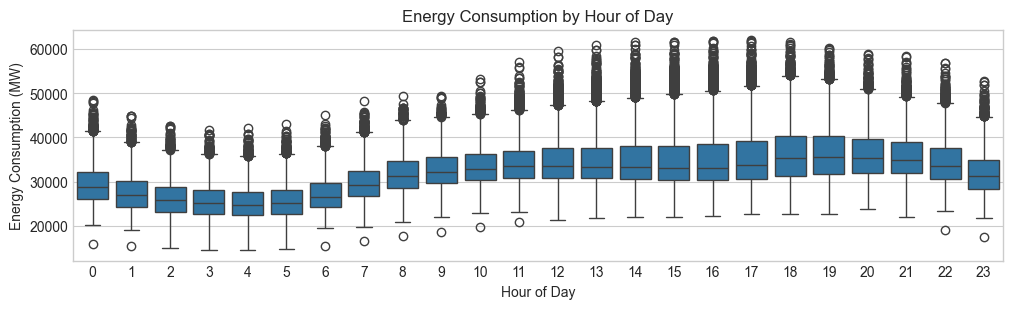


--- Visualizing Weekly Seasonality ---


/var/folders/6z/nc_kvf7x0_sffwplx2dck6f00000gn/T/ipykernel_93948/3002222192.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun'])


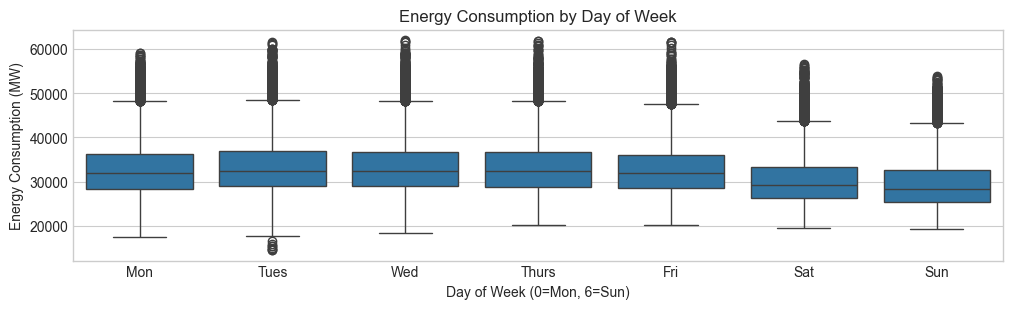

In [8]:
# --- Exploratory Data Analysis (EDA) ---

# 1. Time Plot of a single year to show annual seasonality
print("--- Exploratory Data Analysis ---")
fig, ax = plt.subplots(figsize=(12, 3))
df.loc['2016-01-01':'2016-12-31']['energy_mw'].plot(ax=ax)
ax.set_title('Hourly Energy Consumption for 2016')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (MW)')
plt.show()

# 2. Box plot by Hour to show daily seasonality
print("\n--- Visualizing Daily Seasonality ---")
df_viz = df.copy()
df_viz['hour'] = df_viz.index.hour
df_viz['dayofweek'] = df_viz.index.dayofweek

fig, ax = plt.subplots(figsize=(12, 3))
sns.boxplot(data=df_viz, x='hour', y='energy_mw', ax=ax)
ax.set_title('Energy Consumption by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Energy Consumption (MW)')
plt.show()

# 3. Box plot by Day of Week to show weekly seasonality
print("\n--- Visualizing Weekly Seasonality ---")
fig, ax = plt.subplots(figsize=(12, 3))
sns.boxplot(data=df_viz, x='dayofweek', y='energy_mw', ax=ax)
ax.set_title('Energy Consumption by Day of Week')
ax.set_xlabel('Day of Week (0=Mon, 6=Sun)')
ax.set_ylabel('Energy Consumption (MW)')
ax.set_xticklabels(['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun'])
plt.show()


#### Feature Engineering

In [9]:
def create_features(df):
    """
    Creates time series features from a datetime index.
    """
    df_feat = df.copy()
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['quarter'] = df_feat.index.quarter
    df_feat['month'] = df_feat.index.month
    df_feat['year'] = df_feat.index.year
    df_feat['dayofyear'] = df_feat.index.dayofyear
    return df_feat

df_features = create_features(df)

def add_lags(df):
    """
    Adds lag and rolling features to the dataframe.
    """
    df_lags = df.copy()
    # Lag features
    df_lags['lag1'] = df_lags['energy_mw'].shift(1)
    df_lags['lag24'] = df_lags['energy_mw'].shift(24) # Previous day
    df_lags['lag168'] = df_lags['energy_mw'].shift(168) # Previous week
    
    # Rolling window features
    df_lags['rolling_mean_24'] = df_lags['energy_mw'].rolling(window=24).mean().shift(1)
    df_lags['rolling_std_24'] = df_lags['energy_mw'].rolling(window=24).std().shift(1)
    
    return df_lags.dropna()

df_model_data = add_lags(df_features)

print("--- Feature Engineered DataFrame ---")
print(df_model_data.head())


--- Feature Engineered DataFrame ---
                     energy_mw  hour  dayofweek  quarter  month  year  \
Datetime                                                                
2002-01-08 01:00:00    29445.0     1          1        1      1  2002   
2002-01-08 02:00:00    28670.0     2          1        1      1  2002   
2002-01-08 03:00:00    28375.0     3          1        1      1  2002   
2002-01-08 04:00:00    28542.0     4          1        1      1  2002   
2002-01-08 05:00:00    29261.0     5          1        1      1  2002   

                     dayofyear     lag1    lag24   lag168  rolling_mean_24  \
Datetime                                                                     
2002-01-08 01:00:00          8  31187.0  26862.0  30393.0     33452.583333   
2002-01-08 02:00:00          8  29445.0  25976.0  29265.0     33560.208333   
2002-01-08 03:00:00          8  28670.0  25641.0  28357.0     33672.458333   
2002-01-08 04:00:00          8  28375.0  25666.0  27899.0    

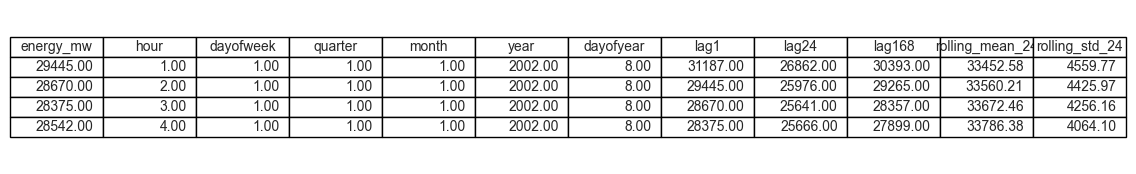

In [10]:
pd.set_option('display.float_format', '{:.2f}'.format)

fig, ax = plt.subplots(figsize=(12,2))  # adjust size
ax.axis('tight')
ax.axis('off')

cell_text = df_model_data.head(4).applymap(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x).values

table = ax.table(cellText=cell_text, colLabels=df_model_data.columns, loc='center')


# Increase font size and scale
table.auto_set_font_size(False)   # disable auto-scaling
table.set_fontsize(10)            # increase font size
table.scale(1.2, 1.2)             # scale width & height of cells

plt.show()

#### Model Training and Hyperparameter Tuning

In [11]:
# --- Model Training and Hyperparameter Tuning ---

# Chronological train-test split
split_date = '2018-01-01 00:00:00'
train = df_model_data.loc[df_model_data.index < split_date]
test = df_model_data.loc[df_model_data.index >= split_date]

X_train = train.drop('energy_mw', axis=1)
y_train = train['energy_mw']
X_test = test.drop('energy_mw', axis=1)
y_test = test['energy_mw']

# Define and train the XGBoost model
# These hyperparameters are chosen for demonstration; in practice, they should be tuned.
reg = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

print("\n--- Training XGBoost Model ---")
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False) # Set to True to see training progress



print("Model training complete.")




--- Training XGBoost Model ---
Model training complete.


#### Evaluation and Feature Importance


--- Evaluating Model Performance ---
Root Mean Squared Error (RMSE) on Test Set: 606.59 MW


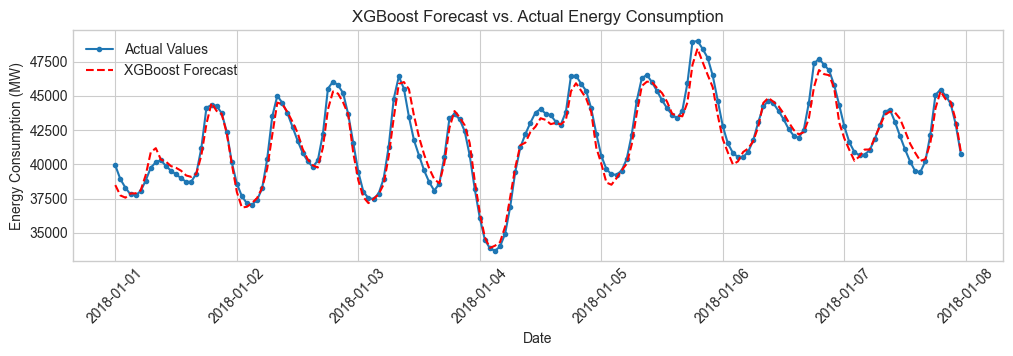


--- Feature Importance ---


/var/folders/6z/nc_kvf7x0_sffwplx2dck6f00000gn/T/ipykernel_93948/4288905285.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance['importance'], y=feature_importance.index, ax=ax, palette='viridis')


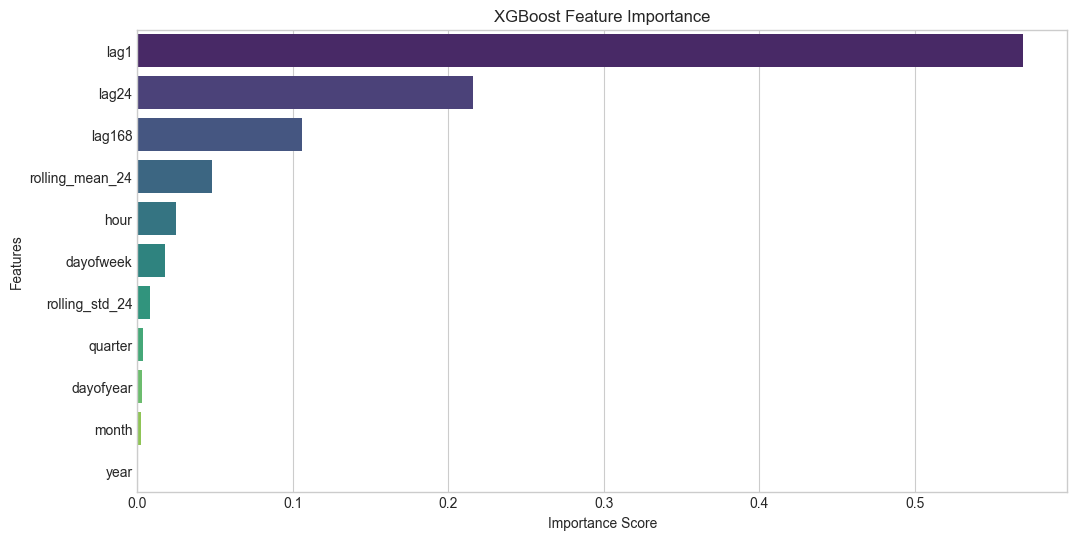

In [12]:
# --- Evaluation and Feature Importance ---

# 1. Generate predictions on the test set
print("\n--- Evaluating Model Performance ---")
y_pred = reg.predict(X_test)

# 2. Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error (RMSE) on Test Set: {rmse:.2f} MW')

# 3. Plot forecasts vs. actuals for a portion of the test set
test_subset = test.iloc[:24*7] # First week of the test set
#y_pred_subset = y_pred[:24*7]

y_pred_subset = pd.Series(y_pred, index =y_test.index)[:24*7]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(test_subset.index, test_subset['energy_mw'], label='Actual Values', marker='.', linestyle='-')
ax.plot(y_pred_subset.index, y_pred_subset, label='XGBoost Forecast', color='red', linestyle='--')
ax.set_title('XGBoost Forecast vs. Actual Energy Consumption')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (MW)')
ax.legend()
plt.xticks(rotation=45)
plt.show()


# 4. Plot feature importance
print("\n--- Feature Importance ---")
feature_importance = pd.DataFrame(data=reg.feature_importances_,
                                  index=reg.feature_names_in_,
                                  columns=['importance'])
feature_importance.sort_values('importance', ascending=False, inplace=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=feature_importance['importance'], y=feature_importance.index, ax=ax, palette='viridis')
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Features')
plt.show()


## <span style="color:blue"> Case Study 3: Stock Price Prediction with LSTM


#### Load Libraries

In [13]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

2025-12-10 08:00:01.499896: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### Data Preparation for LSTMs

In [17]:
# ---  Data Preparation for LSTMs ---

# Fetch GOOGL daily stock price data
googl_data = yf.download('GOOGL', start='2015-01-01', end='2022-12-31')

# We will use the 'Close' price for this univariate forecast
close_prices = googl_data['Close'].values.reshape(-1, 1)

# Split data into training and test sets (80% train, 20% test)
training_data_len = int(np.ceil(len(close_prices) * .8))

# Scale the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_prices)

# Create the training data set
train_data = scaled_data[0:int(training_data_len), :]

# Split the data into x_train and y_train data sets
x_train = []
y_train = []
n_steps = 60 # Number of past days to use for prediction

for i in range(n_steps, len(train_data)):
    x_train.append(train_data[i-n_steps:i, 0])
    y_train.append(train_data[i, 0])

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data into the 3D format required by LSTMs
# (samples, timesteps, features)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print("--- Data Preparation ---")
print(f"Total data points: {len(close_prices)}")
print(f"Training data points: {len(train_data)}")
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

# Create the testing data set
test_data = scaled_data[training_data_len - n_steps:, :]
x_test = []
y_test = close_prices[training_data_len:, :]
for i in range(n_steps, len(test_data)):
    x_test.append(test_data[i-n_steps:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

[*********************100%***********************]  1 of 1 completed

--- Data Preparation ---
Total data points: 2014
Training data points: 1612
Shape of x_train: (1552, 60, 1)
Shape of y_train: (1552,)
Shape of x_test: (402, 60, 1)
Shape of y_test: (402, 1)


#### Building and Training an LSTM Model

2025-12-09 22:26:54.481256: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-09 22:26:54.481582: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-12-09 22:26:54.863936: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-09 22:26:54.865094: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] 


--- LSTM Model Summary ---
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 50)            10400     
                                                                 
 dropout (Dropout)           (None, 60, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 30,651
Trainable params: 30,651
Non-trainable params: 0
_________________________________________________________________

--- Training LSTM Model

2025-12-09 22:26:55.318123: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-09 22:26:55.318953: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-12-09 22:26:55.319824: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

49/49 [==============================] - 6s 33ms/step - loss: 0.0091
Epoch 2/25
49/49 [==============================] - 1s 24ms/step - loss: 8.2382e-04
Epoch 3/25
49/49 [==============================] - 1s 24ms/step - loss: 7.0438e-04
Epoch 4/25
49/49 [==============================] - 1s 23ms/step - loss: 5.3020e-04
Epoch 5/25
49/49 [==============================] - 1s 24ms/step - loss: 4.8064e-04
Epoch 6/25
49/49 [==============================] - 1s 23ms/step - loss: 4.2044e-04
Epoch 7/25
49/49 [==============================] - 1s 24ms/step - loss: 3.1180e-04
Epoch 8/25
49/49 [==============================] - 1s 25ms/step - loss: 3.1825e-04
Epoch 9/25
49/49 [==============================] - 1s 24ms/step - loss: 3.3150e-04
Epoch 10/25
49/49 [==============================] - 1s 24ms/step - loss: 2.7908e-04
Epoch 11/25
49/49 [==============================] - 1s 24ms/step - loss: 2.5518e-04
Epoch 12/25
49/49 [==============================] - 1s 24ms/step - loss: 2.4942e-04
Epoc

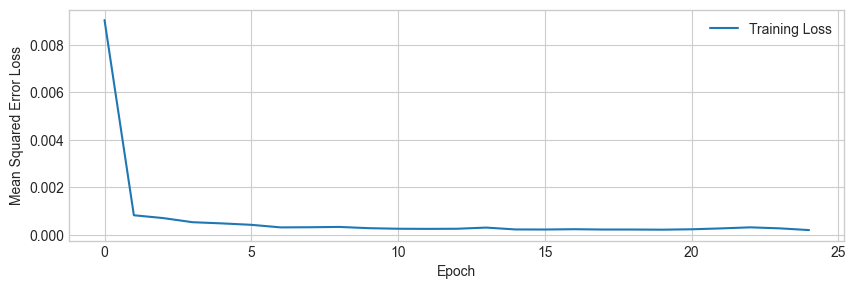

In [18]:
# --- Building and Training an LSTM Model ---

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Print the model summary
print("\n--- LSTM Model Summary ---")
model.summary()

# Train the model
print("\n--- Training LSTM Model ---")
# For a real application, use more epochs and consider callbacks like EarlyStopping
history = model.fit(x_train, y_train, batch_size=32, epochs=25) # Using 25 epochs for demonstration

# Plot training loss
plt.figure(figsize=(10, 3))
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Model Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.show()


#### Evaluation and Interpretation of Results


--- Generating Predictions on Test Data ---


2025-12-09 22:31:16.393755: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-09 22:31:16.394901: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-12-09 22:31:16.395750: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

 1/13 [=>............................] - ETA: 7s

2025-12-09 22:31:16.670688: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-09 22:31:16.756243: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


13/13 [==============================] - 1s 31ms/step
Root Mean Squared Error (RMSE) on Test Set: $3.78


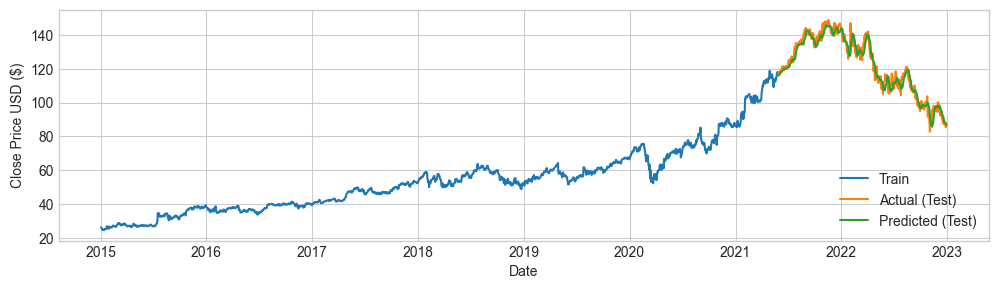

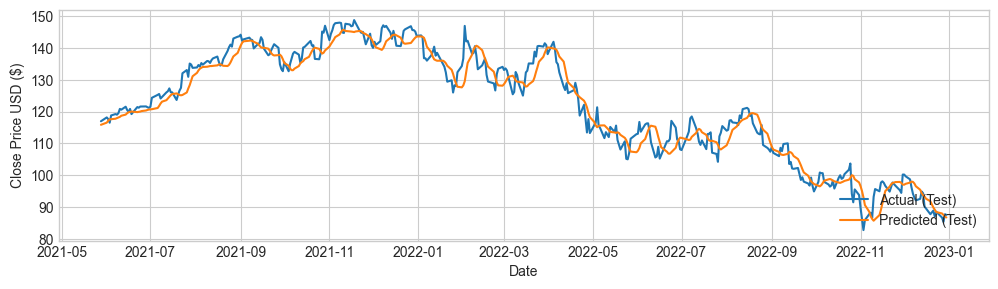

In [19]:
# --- Evaluation and Interpretation of Results ---

# 1. Get the model's predicted price values
print("\n--- Generating Predictions on Test Data ---")
predictions_scaled = model.predict(x_test)
predictions = scaler.inverse_transform(predictions_scaled)

# 2. Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print(f'Root Mean Squared Error (RMSE) on Test Set: ${rmse:.2f}')

# 3. Plot the data
train = googl_data[:training_data_len]
valid = googl_data[training_data_len:]
valid['Predictions'] = predictions

# Visualize the data
plt.figure(figsize=(12, 3))
plt.title('GOOGL Stock Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Actual (Test)', 'Predicted (Test)'], loc='lower right')
plt.grid(True)
plt.show()

# Zoom in on the validation period
plt.figure(figsize=(12, 3))
plt.title('GOOGL Stock Price Prediction (Test Set Detail)')
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Actual (Test)', 'Predicted (Test)'], loc='lower right')
plt.grid(True)
plt.show()


## <span style="color:blue">Case Study 4: Anomaly Detection in Sensor Data

#### Load Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')


#### Load Dataset

In [48]:

# Load the dataset
# Source: Numenta Anomaly Benchmark (NAB) - https://github.com/numenta/NAB
# url = 'https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv'
df = pd.read_csv("./machine_temperature_system_failure.csv", index_col='timestamp', parse_dates=True)
df.columns = ['temperature']
df = df.head(8000)
 

# Ensure numeric and handle small gaps
df['temperature'] = pd.to_numeric(df['temperature'], errors='coerce')
df['temperature'] = df['temperature'].interpolate(limit_direction='both')



#### Data Exploration and Pattern Identification

--- Exploratory Data Analysis ---


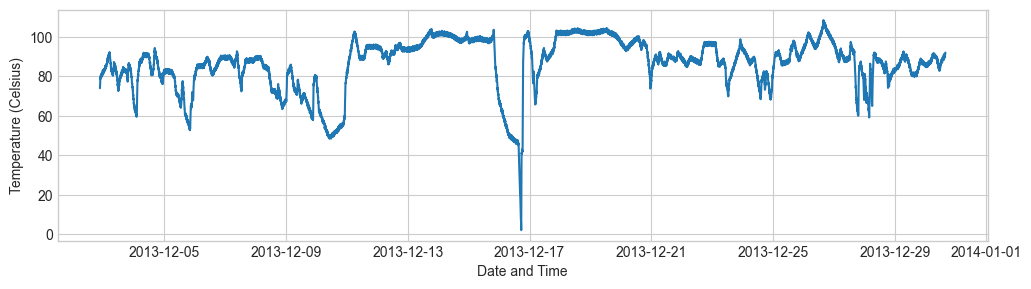


--- Time Series Decomposition (Seasonal Period: 288) ---


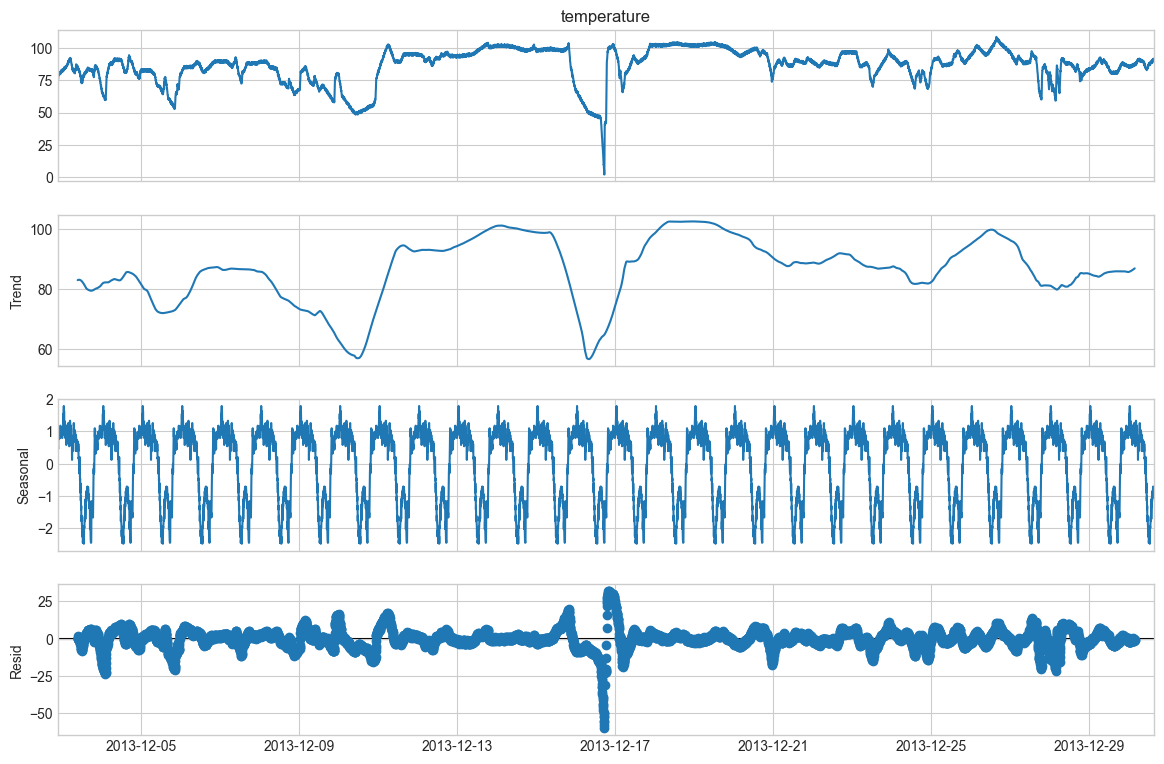

In [50]:
# --- Data Exploration and Pattern Identification ---

# 1. Time Plot of the entire series
print("--- Exploratory Data Analysis ---")
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(df.index, df['temperature'])
ax.set_title('Server Temperature Over Time')
ax.set_xlabel('Date and Time')
ax.set_ylabel('Temperature (Celsius)')
plt.show()

# 2. Time Series Decomposition
# The seasonal period is daily. Since data is every 5 mins, the period is 24 * (60/5) = 288
seasonal_period = 288
print(f"\n--- Time Series Decomposition (Seasonal Period: {seasonal_period}) ---")
decomposition = sm.tsa.seasonal_decompose(df['temperature'], model='additive', period=seasonal_period)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Additive Decomposition of Server Temperature', y=1.02)
plt.tight_layout(pad=2.0)
plt.show()


#### Model-Based Anomaly Detection (Using Residuals)

In [25]:
# ---------------------------
#  Choose a short training window
#    (fast & stable; still models daily cycle)
# ---------------------------
# e.g., first 14 days of data (adjust if your dataset is shorter/longer)
end_train = df.index.min() + pd.Timedelta(days=14)
train = df.loc[:end_train, 'temperature'].copy()
full = df['temperature']

# Safety if dataset is short
if train.shape[0] < s * 3:
    # at least ~3 seasonal cycles
    train = df[y_col].iloc[: s * 3 + 1]

# ---------------------------
#  Fit a small SARIMA quickly
#    Use seasonal differencing only to reduce drift:
#    order = (1,0,1), seasonal_order = (1,1,0,s)
# ---------------------------
# If data are 5-min samples, one day seasonality is 288
# If your data aren’t 5-min, you can change s below accordingly.

s = 288


model = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 0, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Keep it light: few iterations + low memory - for shake of understanding
res = model.fit(disp=False, maxiter=10, low_memory=True)

# ---------------------------
# One-step predictions across the FULL series
# ---------------------------
pred = res.get_prediction(start=full.index[0], end=full.index[-1], dynamic=False)
yhat = pred.predicted_mean.reindex(full.index)  # align to full index

# Residuals (drop leading NaNs from model warmup)
residuals = (full - yhat).dropna()

# ---------------------------
#  Adaptive anomaly threshold (rolling 3σ)
#    Avoids "everything red" after small bias changes
# ---------------------------
# Rolling window ≈ 1 day of 5-min points
win = s
roll_std = residuals.rolling(win, min_periods=int(win/2)).std()

# Use a small floor to avoid zero std in very smooth periods
eps = 1e-6
upper = 3.0 * (roll_std + eps)
lower = -upper

anomalies_mask = (residuals > upper) | (residuals < lower)
anomalies = residuals[anomalies_mask]

print(f"Detected {anomalies.shape[0]} anomalies out of {residuals.shape[0]} points.")

# ---------------------------
#  (Optional) Also compute classic fixed threshold
#    based on training residuals for comparison
# ---------------------------
train_pred = res.get_prediction(start=train.index[0], end=train.index[-1], dynamic=False)
train_resid = (train - train_pred.predicted_mean).dropna()
fixed_thr = 3.0 * train_resid.std()
print(f"(Fixed 3σ from training) threshold ≈ ±{fixed_thr:.2f}")


/Users/ravindra/opt/anaconda3/envs/research38/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 5T will be used.
  self._init_dates(dates, freq)
/Users/ravindra/opt/anaconda3/envs/research38/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 5T will be used.
  self._init_dates(dates, freq)


Detected 218 anomalies out of 8000 points.
(Fixed 3σ from training) threshold ≈ ±9.03


#### Evaluating Detection Performance 

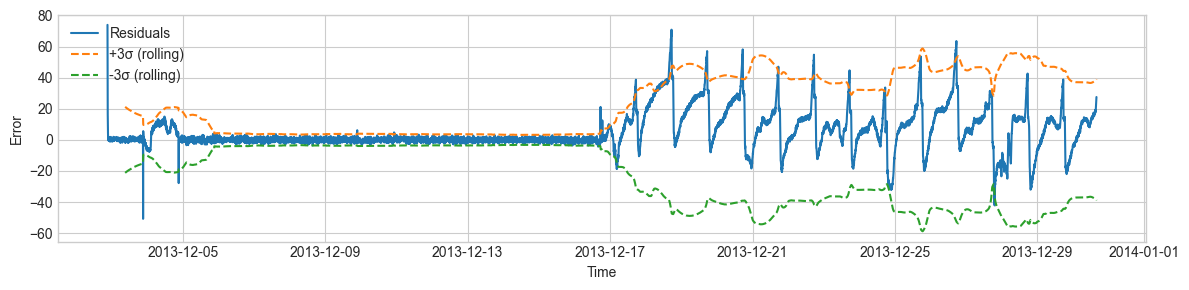

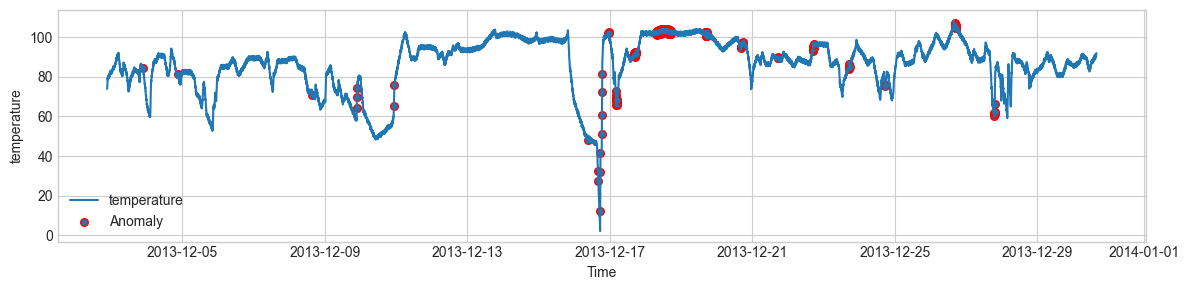

In [35]:
# --- Evaluating Detection Performance ---

# 1. Plot residuals and threshold
plt.figure(figsize=(12, 3))
plt.plot(residuals.index, residuals.values, label="Residuals")
plt.plot(upper.index, upper.values, linestyle="--", label="+3σ (rolling)")
plt.plot(lower.index, lower.values, linestyle="--", label="-3σ (rolling)")
plt.title("Residuals with Adaptive 3σ Bands")
plt.xlabel("Time"); plt.ylabel("Error")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()


# 2. Plot original series with detected anomalies highlighted
anom_y = full.loc[anomalies.index]
plt.figure(figsize=(12, 3))
plt.plot(full.index, full.values, label='temperature')
plt.scatter(anom_y.index, anom_y.values, s=30, label="Anomaly", edgecolor="red")
plt.title("Anomalies on Original Series (Adaptive 3σ)")
plt.xlabel("Time"); plt.ylabel('temperature')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()


## <span style="color:blue">Case Study 5: Weather Forecasting Using Advanced Deep Learning

#### Load Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Force eager execution to avoid TensorFlow 1.x-style graph placeholders (e.g., split_dim) that cause kernel crashes.
tf.config.run_functions_eagerly(True)


2025-12-09 23:01:26.434469: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### Data Preparation for a CNN-LSTM Model

In [2]:
# --- Data Preparation for a CNN-LSTM Model ---

# Load the dataset
# Source: Kaggle - https://www.kaggle.com/datasets/mnassrib/jena-climate/
# For reproducibility, using a direct link to a pre-prepared zip file
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    extract=True
)
csv_path, _ = os.path.splitext(zip_path)
df = pd.read_csv(csv_path)


In [3]:
df['Date Time']= pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.sort_values(by='Date Time')

# Subsample to hourly data
df = df[5::6] # Select every 6th row, starting from the 5th row (index 5)


# df = df.sort_index()
# Select relevant features
features_to_use = ['Date Time','T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)']
df = df[features_to_use]
df.columns = ['Date Time','temp_C', 'pressure_mbar', 'humidity_perc', 'wind_vel_ms']

df = df.reset_index(drop=True)



#### Standardize the data

In [4]:
# --- Scaling ---
# Split data before scaling
split_fraction = 0.7
train_split = int(split_fraction * int(df.shape[0]))

df_train = df.loc[0 : train_split - 1]
df_val = df.loc[train_split:]

date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')
date_time_train = pd.to_datetime(df_train.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')
date_time_val = pd.to_datetime(df_val.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')

# # Calculate mean and std from training data only
# train_mean = df_train.mean()
# train_std = df_train.std()

# # Standardize the data
# df_train_scaled = (df_train - train_mean) / train_std
# df_val_scaled = (df_val - train_mean) / train_std


scaler = StandardScaler().fit(df_train.values)
df_train_scaled = scaler.transform(df_train.values)
df_val_scaled   = scaler.transform(df_val.values)



#### Data Generator Function

In [5]:
def create_dataset(data, target_col_index, lookback, horizon):
    X, y = [], []
    for i in range(len(data) - lookback - horizon):
        X.append(data[i:(i + lookback)])
        y.append(data[i + lookback:i + lookback + horizon, target_col_index])
    return np.array(X), np.array(y)

# Define parameters
LOOKBACK = 120 # 5 days of hourly data
HORIZON = 12   # 12 hours of future data to predict

# Create datasets
#x_train, y_train = create_dataset(df_train_scaled.values, 0, LOOKBACK, HORIZON)
#x_val, y_val = create_dataset(df_val_scaled.values, 0, LOOKBACK, HORIZON)

x_train, y_train = create_dataset(df_train_scaled, 0, LOOKBACK, HORIZON)
x_val, y_val = create_dataset(df_val_scaled, 0, LOOKBACK, HORIZON)

print("--- Data Preparation ---")
print(f"Shape of x_train: {x_train.shape}") # (Samples, Timesteps, Features)
print(f"Shape of y_train: {y_train.shape}")   # (Samples, Horizon)
print(f"Shape of x_val: {x_val.shape}")
print(f"Shape of y_val: {y_val.shape}")

--- Data Preparation ---
Shape of x_train: (48931, 120, 4)
Shape of y_train: (48931, 12)
Shape of x_val: (20896, 120, 4)
Shape of y_val: (20896, 12)


#### Building and Training a Hybrid Model

In [6]:
# --- Building and Training a Hybrid Model ---

# Define the CNN-LSTM model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(LOOKBACK, x_train.shape[-1])))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(units=50, activation='relu'))
model.add(Dense(units=HORIZON))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Print the model summary
print("\n--- CNN-LSTM Model Summary ---")
model.summary()

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
print("\n--- Training CNN-LSTM Model ---")
history = model.fit(x_train, y_train,
                    epochs=20, # For a real application, more epochs would be used
                    batch_size=256,
                    validation_data=(x_val, y_val),
                    callbacks=[early_stopping],
                    verbose=1)

2025-12-09 23:01:38.374104: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-09 23:01:38.374275: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



--- CNN-LSTM Model Summary ---
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 116, 32)           672       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 58, 32)           0         
 )                                                               
                                                                 
 lstm (LSTM)                 (None, 50)                16600     
                                                                 
 dense (Dense)               (None, 12)                612       
                                                                 
Total params: 17,884
Trainable params: 17,884
Non-trainable params: 0
_________________________________________________________________

--- Training CNN-LSTM Model ---
Epoch 1/20


/Users/ravindra/opt/anaconda3/envs/research38/lib/python3.8/site-packages/tensorflow/python/data/ops/structured_function.py:254: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


192/192 [==============================] - 95s 487ms/step - loss: 0.2470 - val_loss: 3422.2522
Epoch 2/20
192/192 [==============================] - 93s 486ms/step - loss: 0.0877 - val_loss: 1282.8026
Epoch 3/20
192/192 [==============================] - 96s 501ms/step - loss: 0.0726 - val_loss: 863.1519
Epoch 4/20
192/192 [==============================] - 94s 491ms/step - loss: 0.0671 - val_loss: 1502.2737
Epoch 5/20
192/192 [==============================] - 94s 488ms/step - loss: 0.0640 - val_loss: 726.5845
Epoch 6/20
192/192 [==============================] - 95s 496ms/step - loss: 0.0612 - val_loss: 1932.5647
Epoch 7/20
192/192 [==============================] - 96s 500ms/step - loss: 0.0593 - val_loss: 4326.7402
Epoch 8/20
192/192 [==============================] - 98s 512ms/step - loss: 0.0576 - val_loss: 447.7505
Epoch 9/20
192/192 [==============================] - 99s 518ms/step - loss: 0.0561 - val_loss: 2072.2124
Epoch 10/20
192/192 [==============================] - 103s 

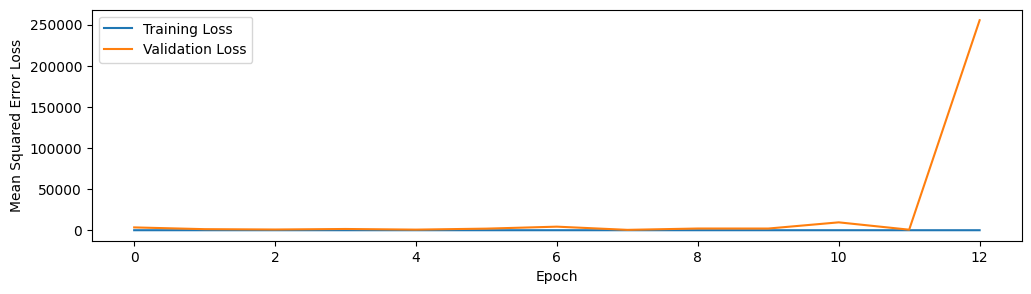

In [7]:
# Plot training and validation loss
plt.figure(figsize=(12, 3))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.show()

#### Evaluation of Multi-Step Forecasts

In [8]:
# --- Evaluation of Multi-Step Forecasts ---

# Generate predictions on a sample from the validation set
sample_index = 0
sample_prediction_scaled = model.predict(x_val[sample_index:sample_index+1])

# Inverse transform the prediction and the actual values
# We need to create a dummy array with the shape of the original data
# and fill the temperature column with our values to use the scaler.

# For predictions
dummy_pred = np.zeros((sample_prediction_scaled.shape[1], df_train_scaled.shape[1]))
dummy_pred[:, 0] = sample_prediction_scaled[0, :]
sample_prediction_original = scaler.inverse_transform(dummy_pred)[:, 0]

#sample_prediction_original = (dummy_pred[:, 0] * train_std[0])+train_mean[0]

# For actuals
dummy_actual = np.zeros((y_val[sample_index].shape[0], df_train_scaled.shape[1]))
dummy_actual[:, 0] = y_val[sample_index]
sample_actual_original = scaler.inverse_transform(dummy_actual)[:, 0]
#sample_actual_original = (dummy_actual[:, 0] * train_std[0])+train_mean[0]

1/1 [==============================] - 1s 807ms/step


In [9]:
df_val_plot = df_val[['temp_C']][df_val.index>=49183].head(12).rename(columns={'temp_C':'Actuals'})
df_val_plot.index = date_time_val[date_time_val.index>=49183].head(12)
df_val_plot['Forecast'] = sample_prediction_original

df_val_plot_trained = df_val[['temp_C']][df_val.index<=49183].rename(columns={'temp_C':'Trained'})
df_val_plot_trained.index = date_time_val[date_time_val.index<=49183]

#### Plot the forecast

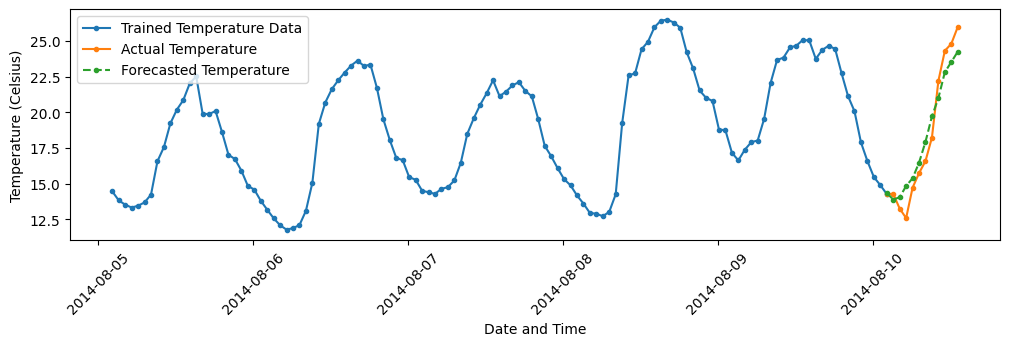

In [11]:


# Get the timestamps for plotting
#last_lookback_ts = df.index[train_split:][sample_index + LOOKBACK - 1]
#forecast_ts = pd.date_range(start=last_lookback_ts + pd.Timedelta(hours=1), periods=HORIZON, freq='H')

# Plot the forecast
plt.figure(figsize=(12, 3))
plt.plot(df_val_plot_trained.index, df_val_plot_trained.Trained.values, label='Trained Temperature Data', marker='.')
plt.plot(df_val_plot.index, df_val_plot.Actuals.values, label='Actual Temperature', marker='.')
plt.plot(df_val_plot.index, df_val_plot.Forecast.values, label='Forecasted Temperature', linestyle='--', marker='.')
plt.title('12-Hour Temperature Forecast vs. Actuals')
plt.xlabel('Date and Time')
plt.ylabel('Temperature (Celsius)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# --- Optional: Calculate MAE for each forecast horizon ---
# This is more computationally intensive as it requires predicting on the whole validation set
# val_predictions_scaled = model.predict(x_val)
# ... then loop through each horizon to calculate and plot MAE ...
